In [876]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

import holidays

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler   # u otros scalers
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import KNNImputer #agregado
from sklearn.pipeline import Pipeline #agregado
from sklearn.model_selection import KFold, cross_val_score #agregado
from sklearn.pipeline import make_pipeline #agregado
from sklearn.compose import ColumnTransformer #agregado

In [877]:
### carga datos de dataset en dataframe
file_path= 'uber_fares.csv'

df = pd.read_csv(file_path)

In [878]:
### visualizacion de algunos datos
df.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


#### Contexto  
El proyecto trata sobre **Uber Inc.**, la compañía de taxis más grande del mundo. En este trabajo, nuestro objetivo es **predecir la tarifa de futuros viajes**.  

Uber brinda servicio a millones de clientes cada día, por lo que gestionar adecuadamente sus datos es clave para desarrollar nuevas estrategias de negocio y obtener mejores resultados.  

### Variables del conjunto de datos  

**Variables explicativas:**  
- **key**: identificador único de cada viaje.  
- **pickup_datetime**: fecha y hora en que se inició el viaje.  
- **passenger_count**: cantidad de pasajeros en el vehículo (dato ingresado por el conductor).  
- **pickup_longitude**: longitud del punto de inicio del viaje.  
- **pickup_latitude**: latitud del punto de inicio del viaje.  
- **dropoff_longitude**: longitud del punto de destino.  
- **dropoff_latitude**: latitud del punto de destino.  

**Variable objetivo (target):**  
- **fare_amount**: costo del viaje en dólares.  

In [879]:
### Columnas, ¿cuáles son variables numéricas y cuales variables categóricas?
df.columns

Index(['key', 'date', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count'],
      dtype='object')

In [880]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


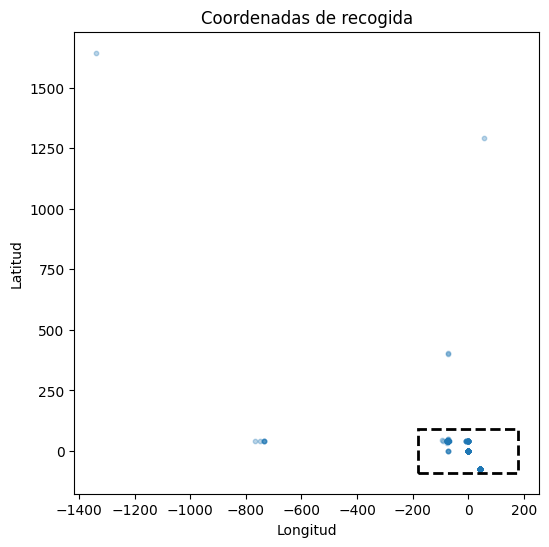

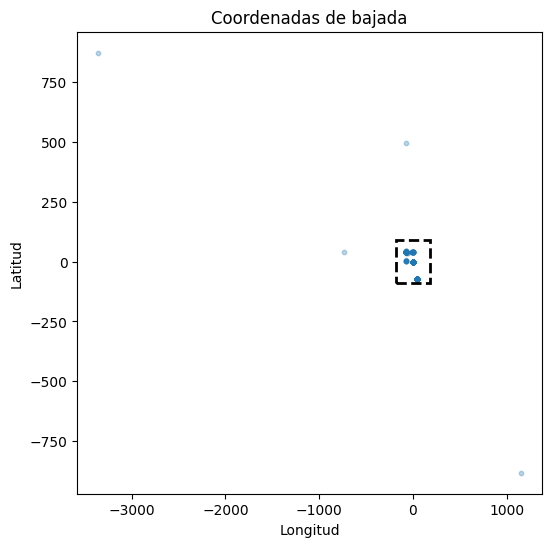

In [881]:
#Coordenadas de Pickup
plt.figure(figsize=(6,6))
plt.scatter(df["pickup_longitude"], df["pickup_latitude"], s=10, alpha=0.3)

world_rect = patches.Rectangle(
    (-180, -90),  
    360,          
    180,           
    linewidth=2, edgecolor='black', facecolor='none', linestyle='--'
)
plt.gca().add_patch(world_rect)

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Coordenadas de recogida")
plt.show()

#Coordenadas de Dropoff
plt.figure(figsize=(6,6))
plt.scatter(df["dropoff_longitude"], df["dropoff_latitude"], s=10, alpha=0.3)

world_rect = patches.Rectangle(
    (-180, -90),  
    360,          
    180,           
    linewidth=2, edgecolor='black', facecolor='none', linestyle='--'
)
plt.gca().add_patch(world_rect)

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Coordenadas de bajada")
plt.show()


***JUSTIFICACION DE POR QUE DROPEAMOS COORDENADAS INVALIDAS***

Primero validamos las coordenadas para evitar que valores inválidos generen distancias absurdas. Incluso dentro del rango [-90,90]/[-180,180]

In [882]:
#Coordenadas reales
lat_min, lat_max = -90, 90  
lon_min, lon_max = -180, 180

valid_pickup_lat = df["pickup_latitude"].between(lat_min, lat_max)
valid_pickup_lon = df["pickup_longitude"].between(lon_min, lon_max)
valid_dropoff_lat = df["dropoff_latitude"].between(lat_min, lat_max)
valid_dropoff_lon = df["dropoff_longitude"].between(lon_min, lon_max)

invalid_counts = (
    (~valid_pickup_lat).astype(int) +
    (~valid_pickup_lon).astype(int) +
    (~valid_dropoff_lat).astype(int) +
    (~valid_dropoff_lon).astype(int)
)

#Dropeamos filas con más de 1 coordenada inválida
df_filtrado = df[invalid_counts <= 1]


#Reemplazamos las coordenadas inválidas con NaN
df_filtrado.loc[~valid_pickup_lat, "pickup_latitude"] = np.nan
df_filtrado.loc[~valid_pickup_lon, "pickup_longitude"] = np.nan
df_filtrado.loc[~valid_dropoff_lat, "dropoff_latitude"] = np.nan
df_filtrado.loc[~valid_dropoff_lon, "dropoff_longitude"] = np.nan
df_filtrado.isna().sum()



 

key                  0
date                 0
fare_amount          0
pickup_datetime      0
pickup_longitude     6
pickup_latitude      2
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

Cantidad de valores negativos en fare_amount: 22
Porcentaje de valores negativos sobre el total de registros en fare_amount: 0.011000165002475037%


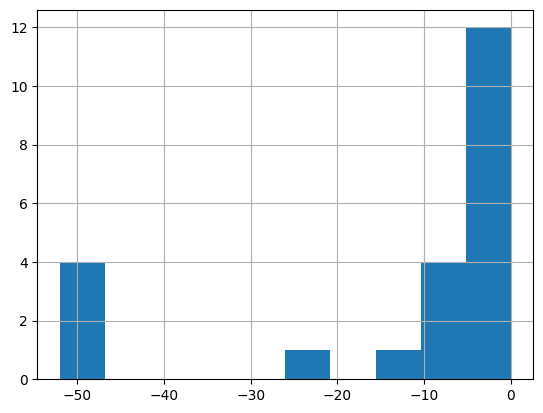

In [883]:
df_filtrado['fare_amount'].isnull().sum() #no hay nulos en fare_amount
df_filtrado[df_filtrado["fare_amount"] <= 0]["fare_amount"].hist()
negativos = df_filtrado[df_filtrado["fare_amount"] <= 0]['fare_amount'].size
print(f"Cantidad de valores negativos en fare_amount: {negativos}")
print(f"Porcentaje de valores negativos sobre el total de registros en fare_amount: {negativos / df_filtrado.fare_amount.size * 100}%")  # porcentaje de negativos en fare_amount
df_filtrado = df_filtrado[df_filtrado['fare_amount'] > 0]  # eliminamos los negativos y ceros


In [884]:
df_filtrado.shape

(199975, 9)

***AGREGAR JUSTIFICACION DE PORQUE BOLETEAMOS LOS NULOS***

<Axes: xlabel='distance_km'>

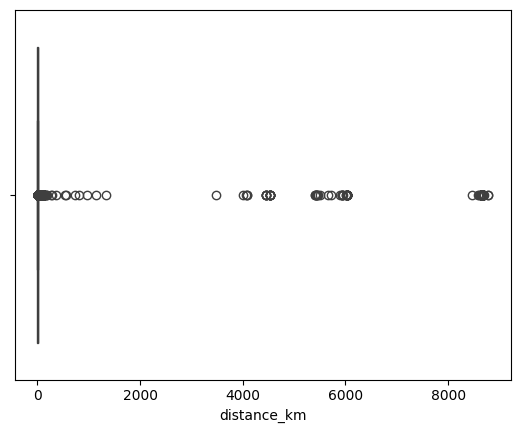

In [885]:
def haversine_km(lat1, lon1, lat2, lon2):
    # retorna distancia en kilómetros (vectorizado)
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c


df_filtrado['distance_km'] = haversine_km(
    df_filtrado['pickup_latitude'], df_filtrado['pickup_longitude'],
    df_filtrado['dropoff_latitude'], df_filtrado['dropoff_longitude']
)

df_filtrado['distance_km'].describe()
sns.boxplot(x=df_filtrado['distance_km'])



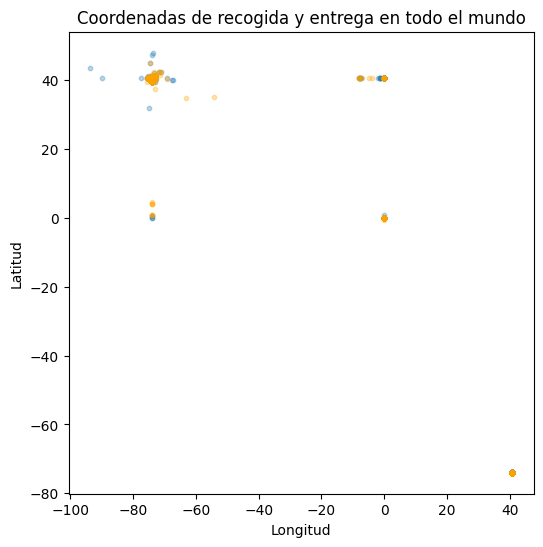

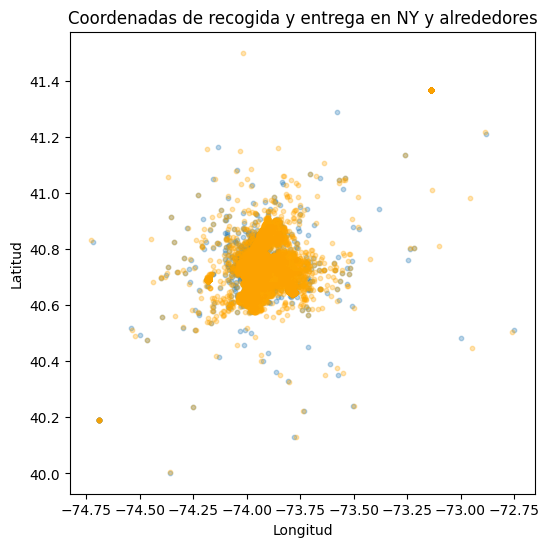

In [886]:
ny_coords = (
    (df_filtrado["pickup_latitude"].between(40, 42)| df_filtrado["pickup_latitude"].isna())&
    (df_filtrado["pickup_longitude"].between(-75, -72) | df_filtrado["pickup_longitude"].isna()) &
    (df_filtrado["dropoff_latitude"].between(40, 42) | df_filtrado["dropoff_latitude"].isna()) &
    (df_filtrado["dropoff_longitude"].between(-75, -72) | df_filtrado["dropoff_longitude"].isna())
)
df_filtrado_ny = df_filtrado[ny_coords].copy()
plt.figure(figsize=(6,6))
plt.scatter(df_filtrado["pickup_longitude"], df_filtrado["pickup_latitude"], s=10, alpha=0.3)
plt.scatter(df_filtrado["dropoff_longitude"], df_filtrado["dropoff_latitude"], s=10, alpha=0.3, color='orange')
plt.xlabel("Longitud")          
plt.ylabel("Latitud")
plt.title("Coordenadas de recogida y entrega en todo el mundo")      
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(df_filtrado_ny["pickup_longitude"], df_filtrado_ny["pickup_latitude"], s=10, alpha=0.3)
plt.scatter(df_filtrado_ny["dropoff_longitude"], df_filtrado_ny["dropoff_latitude"], s=10, alpha=0.3, color='orange')
plt.xlabel("Longitud")          
plt.ylabel("Latitud")
plt.title("Coordenadas de recogida y entrega en NY y alrededores")      
plt.show()

In [887]:
df_filtrado_ny["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"], errors="coerce", utc=True)

df_filtrado_ny["pickup_datetime"] = df_filtrado_ny["pickup_datetime"].dt.tz_convert("America/New_York")

us_holidays = holidays.US(years=df_filtrado_ny["pickup_datetime"].dt.year.unique(), state="NY")

df_filtrado_ny["is_holiday"] = df_filtrado_ny["pickup_datetime"].dt.date.isin(us_holidays).astype(int)


df_filtrado_ny["is_workday"] = (
    (df_filtrado_ny["pickup_datetime"].dt.dayofweek < 4) &  # lunes a jueves
    (~df_filtrado_ny["pickup_datetime"].dt.date.astype('datetime64[ns]').isin(us_holidays))  # feriado o fin de semana
).astype(int)

df_filtrado_ny[[ "is_holiday", "is_workday"]].value_counts()

# Extraer hora
df_filtrado_ny["hora_recogida"] = df_filtrado_ny["pickup_datetime"].dt.hour
## Extraer mes
df_filtrado_ny["mes_recogida"] = df_filtrado_ny["pickup_datetime"].dt.month

##Crear 24 dummies para cada hora del día
hora_dummies = pd.get_dummies(df_filtrado_ny["hora_recogida"], prefix="hora", dtype=int)
df_filtrado_ny = pd.concat([df_filtrado_ny, hora_dummies], axis=1)

##Crear dummies para los 12 meses del año
mes_dummies = pd.get_dummies(df_filtrado_ny["mes_recogida"], prefix="mes", drop_first=True, dtype=int)
df_filtrado_ny = pd.concat([df_filtrado_ny, mes_dummies], axis=1)
#pasar a float las variables categóricas


df_modelo = df_filtrado_ny.drop(columns=["key", "hora_recogida", "pickup_datetime", "date", "mes_recogida"])


C:\Users\Usuario\AppData\Local\Temp\ipykernel_15632\342424317.py:12: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  (~df_filtrado_ny["pickup_datetime"].dt.date.astype('datetime64[ns]').isin(us_holidays))  # feriado o fin de semana


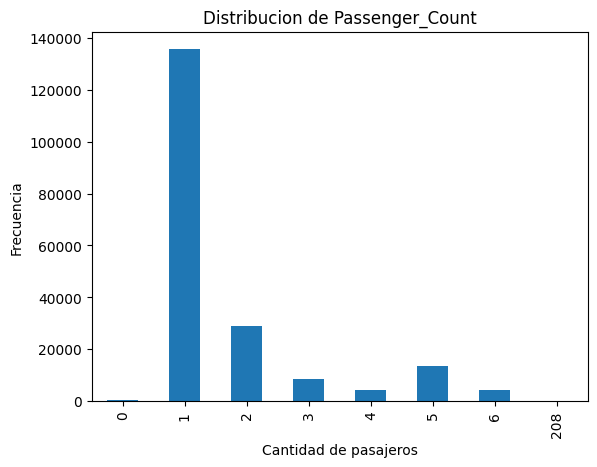

passenger_count
1      135491
2       28835
5       13722
3        8696
6        4184
4        4182
0         686
208         1
Name: count, dtype: int64

In [888]:
df_modelo["passenger_count"].value_counts().sort_index().plot(kind='bar')
plt.title("Distribucion de Passenger_Count")
plt.xlabel("Cantidad de pasajeros")
plt.ylabel("Frecuencia")
plt.show()
df_modelo["passenger_count"].value_counts()


In [889]:
### Creamos una nueva variable dummie con el tipo de viaje por pasajero 

df_modelo["uber_comun"] = df_modelo["passenger_count"].isin([1, 2, 3, 4]).astype(int)
df_modelo["uber_grande"] = df_modelo["passenger_count"].isin([5, 6]).astype(int)
#Convertimos el valor 208 en nulo 
df_modelo["passenger_count"] = df_modelo["passenger_count"].replace(208, np.nan)

Cantidad de viajes con distancia = 0: 2038

Estadísticas de fare_amount en viajes con distancia = 0:
count    2038.000000
mean       11.101305
std        14.647066
min         2.500000
25%         4.900000
50%         6.500000
75%        10.100000
max       200.000000
Name: fare_amount, dtype: float64


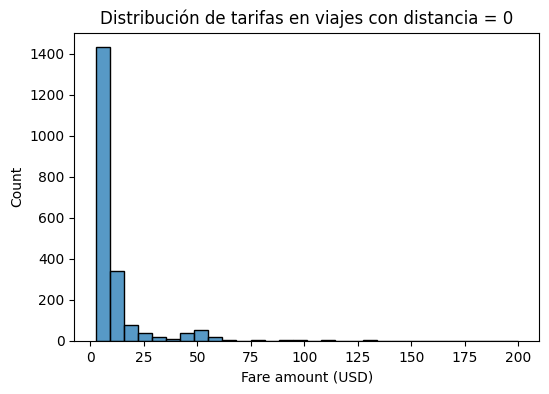

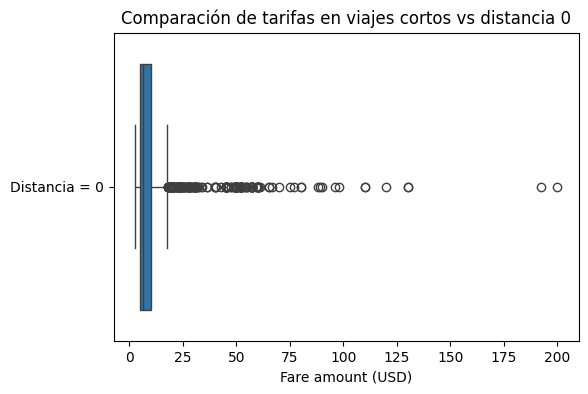

(1012,)

In [890]:
# 1. Contar cuántos viajes tienen distancia 0
zero_dist = df_modelo[df_modelo["distance_km"] == 0]
print("Cantidad de viajes con distancia = 0:", len(zero_dist))

# 2. Describir sus tarifas
print("\nEstadísticas de fare_amount en viajes con distancia = 0:")
print(zero_dist["fare_amount"].describe())

# 3. Histograma de esas tarifas
plt.figure(figsize=(6,4))
sns.histplot(zero_dist["fare_amount"], bins=30, kde=False)
plt.xlabel("Fare amount (USD)")
plt.title("Distribución de tarifas en viajes con distancia = 0")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(
    data=[zero_dist["fare_amount"]],
    orient="h"
)
plt.yticks([0], ["Distancia = 0"])
plt.xlabel("Fare amount (USD)")
plt.title("Comparación de tarifas en viajes cortos vs distancia 0")
plt.show()

zero_dist[zero_dist["fare_amount"] > 6.5]["fare_amount"].shape


De 2000 registros con distancia 0, graficamos y analizamos el target de cada uno, seleccionando como "precio base" hasta 6.5 USD, para tomar como válidos los viajes con distancia 0 y darle una mínima referencia al modelo. Quedaron dropeados 1012 y 925 dentro del dataset.

In [891]:
X_train, X_test, y_train, y_test = train_test_split(df_modelo.drop(columns='fare_amount'), df_modelo['fare_amount'], test_size=0.2, random_state=42)


IMPUTACION DE VALORES FALTANTES EN COORDENADAS Y DISTANCIAS 
--------------------------------------------------------------

In [892]:
coords = ["pickup_latitude","pickup_longitude","dropoff_latitude","dropoff_longitude"]

invalidas = X_train[coords].isna().sum(axis=1)
filas_a_imputar = X_train[invalidas == 1].copy()


scaler = StandardScaler()
X_escaladas_train = scaler.fit_transform(filas_a_imputar[coords])

# 3️⃣ Imputación KNN en X_train
imputer = KNNImputer(n_neighbors=5)
X_imputadas_train = imputer.fit_transform(X_escaladas_train)

# 4️⃣ Volvemos a coordenadas originales en X_train
filas_a_imputar[coords] = scaler.inverse_transform(X_imputadas_train)

# 5️⃣ Reintegrar al X_train original
X_train.update(filas_a_imputar)

# 6️⃣ Imputación en X_test usando los mismos scaler e imputador
invalidas_test = X_test[coords].isna().sum(axis=1)
filas_a_imputar_test = X_test[invalidas_test == 1].copy()

# Escalar X_test con scaler ya ajustado
X_escaladas_test = scaler.transform(filas_a_imputar_test[coords])

# Imputar usando imputador ya ajustado
X_imputadas_test = imputer.transform(X_escaladas_test )

# Volvemos a coordenadas originales en X_test
filas_a_imputar_test[coords] = scaler.inverse_transform(X_imputadas_test)

# Reintegrar al X_test original
X_test.update(filas_a_imputar_test)



C:\Users\Usuario\AppData\Local\Temp\ipykernel_15632\2858692640.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 0]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  X_train.update(filas_a_imputar)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_15632\2858692640.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 1 1 ... 1 0 0]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  X_train.update(filas_a_imputar)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_15632\2858692640.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 0]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  X_train.update(filas_a_imputar)
C:\Users\Usuario

In [893]:
X_train['distance_km'] = haversine_km(
    X_train['pickup_latitude'], X_train['pickup_longitude'],
    X_train['dropoff_latitude'], X_train['dropoff_longitude']
)

X_test['distance_km'] = haversine_km(
    X_test['pickup_latitude'], X_test['pickup_longitude'],
    X_test['dropoff_latitude'], X_test['dropoff_longitude']
)
   

DROP DE COORDENADAS

In [894]:
##Dropeamos pickup_latitude y dropoff_latitude

X_train = X_train.drop(columns=['pickup_latitude', 'dropoff_latitude', 'pickup_longitude', 'dropoff_longitude'])
X_test  = X_test.drop(columns=['pickup_latitude', 'dropoff_latitude', 'pickup_longitude', 'dropoff_longitude'])

df_modelo = df_modelo.drop(columns=['pickup_latitude', 'dropoff_latitude', 'pickup_longitude', 'dropoff_longitude'])

In [895]:


hora_cols = [col for col in X_train.columns if col.startswith("hora_")]

for col in hora_cols:
    X_train[col] = X_train["distance_km"] * X_train[col]

hora_cols_test = [col for col in X_test.columns if col.startswith("hora_")]

for col in hora_cols_test:
    X_test[col] = X_test["distance_km"] * X_test[col]

print(X_train[hora_cols].head())
print(X_test[hora_cols].head())




        hora_0  hora_1  hora_2  hora_3  hora_4  hora_5  hora_6  hora_7  \
35048      0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
192704     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
8207       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
197511     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
156994     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

          hora_8  hora_9  ...  hora_14   hora_15  hora_16   hora_17  hora_18  \
35048   0.000000     0.0  ...      0.0  0.000000      0.0  6.635825      0.0   
192704  0.000000     0.0  ...      0.0  0.000000      0.0  0.000000      0.0   
8207    0.000000     0.0  ...      0.0  9.996973      0.0  0.000000      0.0   
197511  1.799962     0.0  ...      0.0  0.000000      0.0  0.000000      0.0   
156994  0.000000     0.0  ...      0.0  0.000000      0.0  2.924205      0.0   

        hora_19   hora_20  hora_21  hora_22  hora_23  
35048       0.0  0.

IMPUTACION DE LOS VALORES DE FARE_AMOUNT DE LA DISTANCIA MENOR A 0,1


In [896]:
# Encontrar la moda SOLO en el train
zero_dist_train = y_train[X_train["distance_km"] < 0.1]
moda_fare_train = zero_dist_train.mode()[0]

# Imputar en train usando esa moda
y_train.loc[X_train["distance_km"] < 0.1] = moda_fare_train


In [897]:
mask_train = X_train["distance_km"] < 0.1
mask_test  = X_test["distance_km"] < 0.1

# Antes de imputar, podés chequear cuántos casos hay:
print("Filas a imputar en train:", mask_train.sum())
print("Filas a imputar en test:", mask_test.sum())

# Aplicás la moda:
y_train.loc[mask_train] = moda_fare_train


Filas a imputar en train: 2533
Filas a imputar en test: 675


In [898]:
print("Valores únicos en train después de imputar:",
      y_train[mask_train].unique())
print("Valores únicos en test después de imputar:",
      y_test[mask_test].unique())

Valores únicos en train después de imputar: [2.5]
Valores únicos en test después de imputar: [  2.5    9.3    5.7    7.7    3.     6.5    2.9    6.9    7.5    3.25
   7.3    8.     6.1    4.1    4.5    3.7   12.5   45.     4.9   15.5
   7.    18.1   32.2   52.    13.     8.9   12.9    5.3   12.    96.
  10.1   11.5   50.    16.5    8.1    5.5   47.7  142.    11.    25.
  17.    10.     3.3   49.57  16.9   26.9    6.    48.     9.7   49.8
  12.1   56.8   95.    13.5   20.5   20.    13.7   17.7    4.    11.7
  50.5   15.7   24.5   14.5   10.5   35.7   11.3    3.5   13.3   17.5
  20.4   38.     5.    23.7   71.     8.5    7.8   15.3    7.4   19.
  14.9   57.33  18.9  110.    40.    75.    28.1   98.    71.5   14.
  19.5   18.     9.5   40.5   14.1   39.    19.8   10.9  113.    16.
  53.    10.3  200.    39.5   66.81  16.1   55.    58.5   20.1   13.2
   8.6  120.    65.     6.3   17.3 ]


In [899]:
y_train[y_train > 300].sort_values(ascending=False)
y_test[y_test > 300].sort_values(ascending=False)

Series([], Name: fare_amount, dtype: float64)

Ratio Precio/Distancia
-----------------------------------

In [900]:
X_train = X_train.copy()
X_test = X_test.copy()

X_train["costo_por_km"] = np.nan
X_test["costo_por_km"]  = np.nan

# Calculo costo por km
mask_train = X_train["distance_km"] >= 1
mask_test  = X_test["distance_km"]  >= 1

# Calcular costo/km SOLO para esas filas
X_train.loc[mask_train, "costo_por_km"] = (
    np.array(y_train).reshape(-1)[mask_train] / X_train.loc[mask_train, "distance_km"]
)

X_test.loc[mask_test, "costo_por_km"] = (
    np.array(y_test).reshape(-1)[mask_test] / X_test.loc[mask_test, "distance_km"]
)


In [901]:

umbral = 20

# Máscara de outliers
mask_outliers = X_train["costo_por_km"] > umbral

# Calcular media de costo_por_km SOLO en los que no son outliers
mean_cpk = X_train.loc[~mask_outliers, "costo_por_km"].mean()


y_train[mask_outliers] = (
    X_train.loc[mask_outliers, "distance_km"] * mean_cpk
)

print("Outliers detectados:", mask_outliers.sum())
print("Media costo/km usada:", mean_cpk)


Outliers detectados: 56
Media costo/km usada: 3.7778713022672723


IMPUTACION DE PASAJEROS POR LA MODA
-----------------------------------

In [902]:

##imputamos valor nulo de passenger_count por la moda
moda_passenger = X_train["passenger_count"].mode()[0]
X_train["passenger_count"].fillna(moda_passenger, inplace=True)
X_test["passenger_count"].fillna(moda_passenger, inplace=True)  
#Borro passenger_count porque ya tengo las dummies
X_train = X_train.drop(columns=['passenger_count'])
X_test  = X_test.drop(columns=['passenger_count'])
df_modelo = df_modelo.drop(columns=['passenger_count'])

C:\Users\Usuario\AppData\Local\Temp\ipykernel_15632\3537679703.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train["passenger_count"].fillna(moda_passenger, inplace=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_15632\3537679703.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves 

In [903]:
train = pd.concat([X_train, y_train], axis=1)
test = pd.concat([X_test, y_test], axis=1)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (156637, 42)
Test shape: (39160, 42)


In [904]:
print("\n--- Estadísticas TRAIN ---")
print(train.describe(include="all").transpose())

print("\n--- Estadísticas TEST ---")
print(test.describe(include="all").transpose())


--- Estadísticas TRAIN ---
                 count       mean       std       min       25%       50%  \
distance_km   156637.0   3.325664  3.756521  0.000000  1.257801  2.157035   
is_holiday    156637.0   0.029374  0.168852  0.000000  0.000000  0.000000   
is_workday    156637.0   0.548632  0.497631  0.000000  0.000000  1.000000   
hora_0        156637.0   0.054228  0.713503  0.000000  0.000000  0.000000   
hora_1        156637.0   0.064330  0.815474  0.000000  0.000000  0.000000   
hora_2        156637.0   0.097763  0.898266  0.000000  0.000000  0.000000   
hora_3        156637.0   0.123603  0.916151  0.000000  0.000000  0.000000   
hora_4        156637.0   0.139213  0.952438  0.000000  0.000000  0.000000   
hora_5        156637.0   0.137125  0.963774  0.000000  0.000000  0.000000   
hora_6        156637.0   0.139380  1.031716  0.000000  0.000000  0.000000   
hora_7        156637.0   0.142823  0.996514  0.000000  0.000000  0.000000   
hora_8        156637.0   0.151147  1.038793  0.0

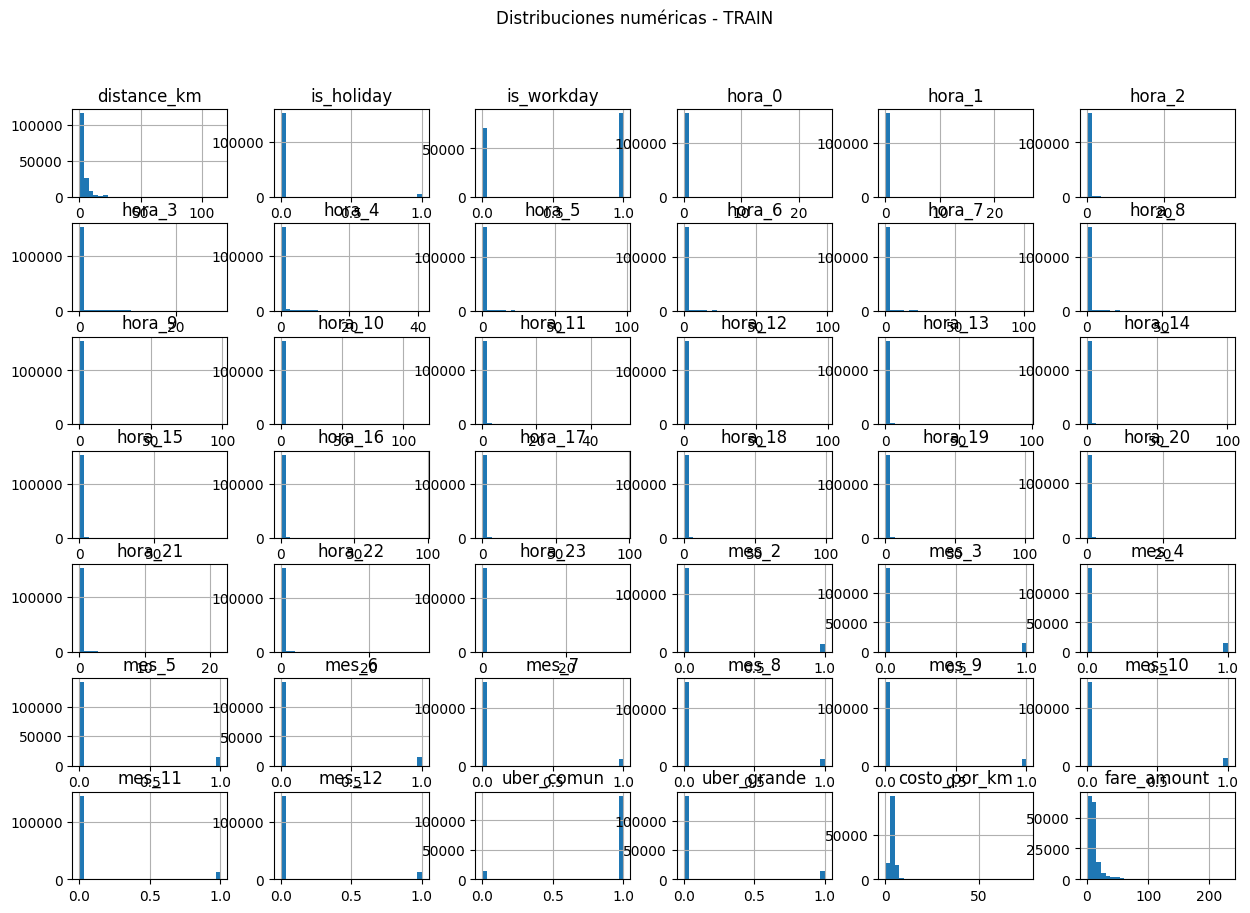

In [905]:
# Histogramas de variables numéricas
num_cols = train.select_dtypes(include=["int64", "float64"]).columns
train[num_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle("Distribuciones numéricas - TRAIN")
plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_15632\549040856.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(train[col], label="Train", shade=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_15632\549040856.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(test[col], label="Test", shade=True)


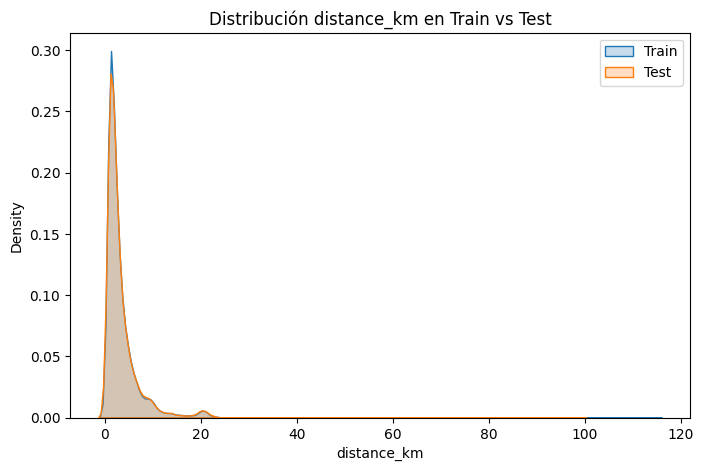

In [906]:

col = "distance_km"  # ejemplo, podés iterar con varias
plt.figure(figsize=(8,5))
sns.kdeplot(train[col], label="Train", shade=True)
sns.kdeplot(test[col], label="Test", shade=True)
plt.title(f"Distribución {col} en Train vs Test")
plt.legend()
plt.show()

***AGREGAR JUSTIFICACION DE QUE VAMOS A HACER CON EL OUTLIER***
No eliminamos filas innecesariamente y no inventamos datos arbitrarios. Usamos la moda porque refleja el valor más frecuente y es consistente con la realidad del dominio (viajes de 1 pasajero).

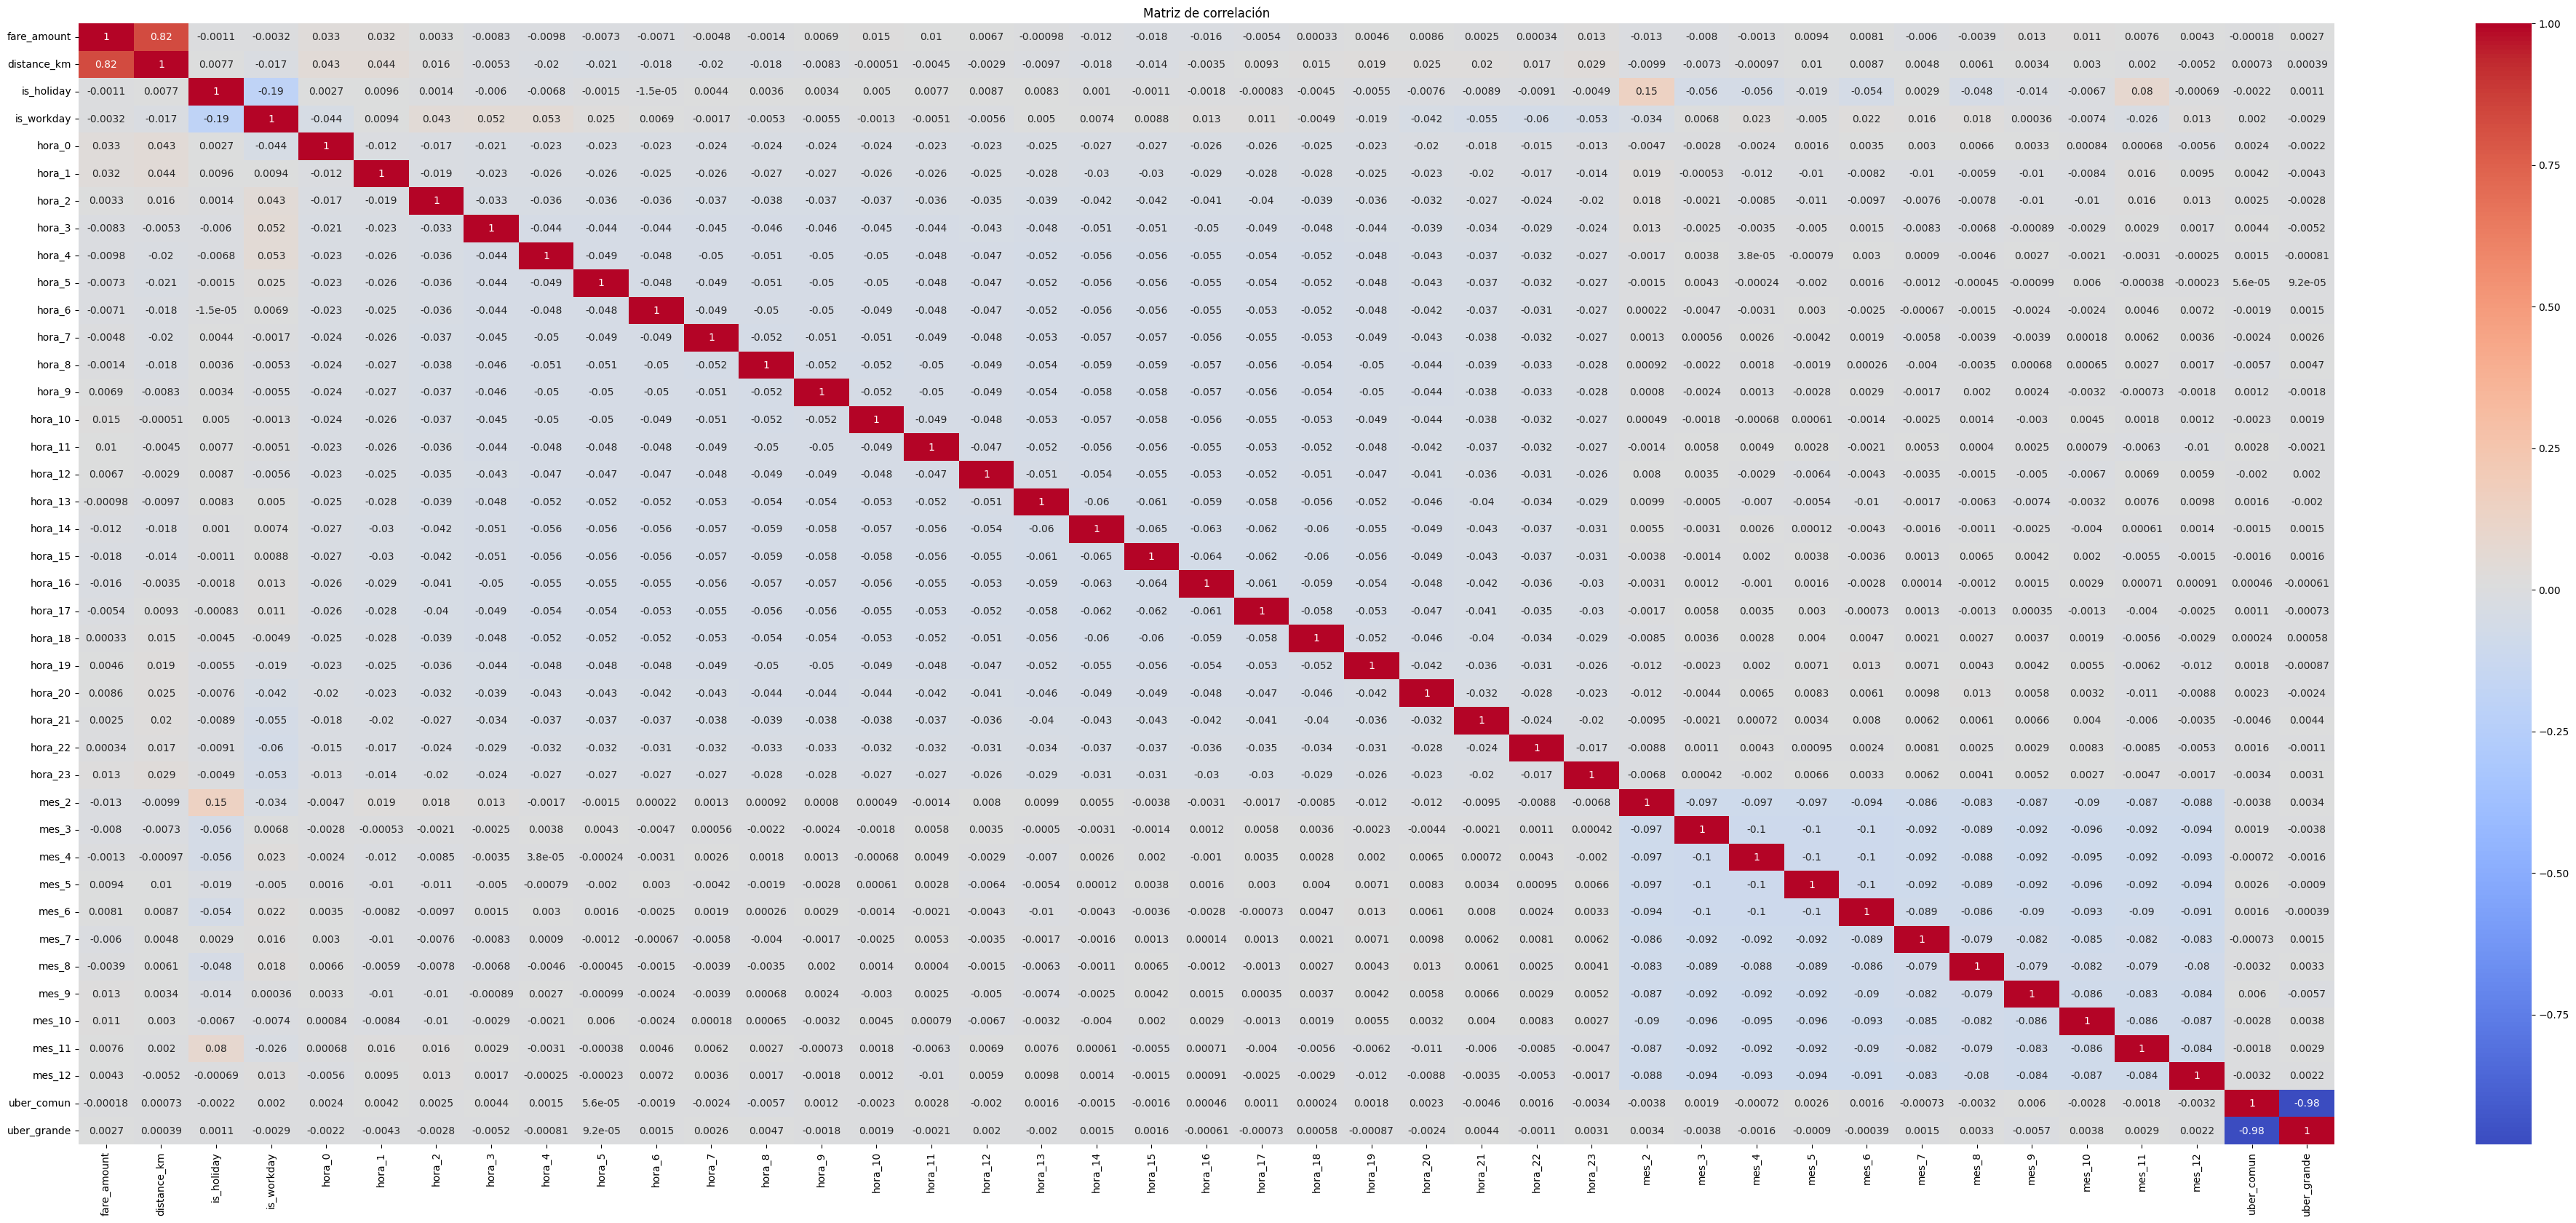

In [907]:
# Supongamos que tus features están en un DataFrame "df"
corr = df_modelo.corr()

plt.figure(figsize=(50,20))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()


distance_km     0.00079
is_holiday      0.00000
is_workday      0.00000
hora_0          0.00079
hora_1          0.00000
hora_2          0.00000
hora_3          0.00000
hora_4          0.00000
hora_5          0.00000
hora_6          0.00000
hora_7          0.00000
hora_8          0.00000
hora_9          0.00000
hora_10         0.00000
hora_11         0.00000
hora_12         0.00000
hora_13         0.00000
hora_14         0.00000
hora_15         0.00000
hora_16         0.00000
hora_17         0.00000
hora_18         0.00000
hora_19         0.00000
hora_20         0.00000
hora_21         0.00000
hora_22         0.00000
hora_23         0.00000
mes_2           0.00000
mes_3           0.00000
mes_4           1.00000
mes_5           0.00000
mes_6           0.00000
mes_7           0.00000
mes_8           0.00000
mes_9           0.00000
mes_10          0.00000
mes_11          0.00000
mes_12          0.00000
uber_comun      1.00000
uber_grande     0.00000
costo_por_km        NaN
Name: 170081, dt

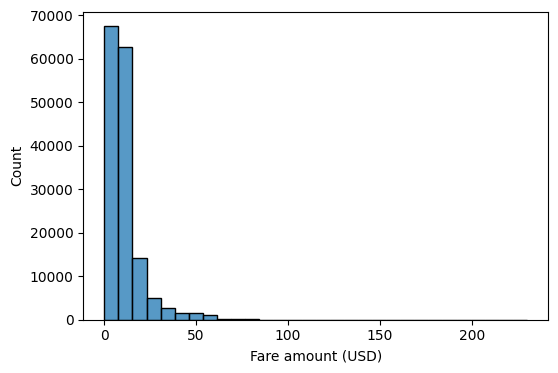

In [908]:
##histograma de fare_amount
plt.figure(figsize=(6,4))   
sns.histplot(y_train, bins=30, kde=False)
plt.xlabel("Fare amount (USD)")
##fare_amount mayores a 200
y_train[y_train > 200]
##ver fila del indice 170081
X_train.loc[170081]



In [909]:
X_train["short_trip"] = ((X_train["distance_km"] < 1) & (X_train["distance_km"] > 0.1)).astype(int)
X_test["short_trip"]  = ((X_test["distance_km"] < 1) & (X_test["distance_km"] > 0.1)).astype(int)

X_train["dist_x_short"] = X_train["distance_km"] * X_train["short_trip"]
X_test["dist_x_short"]  = X_test["distance_km"] * X_test["short_trip"]


In [911]:


# Definimos columnas numéricas y categóricas
num_cols = ["distance_km", "dist_x_short"]
cat_cols = ["is_holiday", "is_workday", "uber_comun", "uber_grande", "mes_2", "mes_3", "mes_4", "mes_5", "mes_6", "mes_7", "mes_8",
            "mes_9", "mes_10", "mes_11", "mes_12", "hora_0","hora_1", "hora_2", "hora_3", "hora_4", "hora_5", "hora_6", "hora_7", "hora_8",
            "hora_9", "hora_10", "hora_11", "hora_12", "hora_13", "hora_14", "hora_15", "hora_16", "hora_17", "hora_18", "hora_19", "hora_20", "hora_21", "hora_22", "hora_23"]

# Preprocesador: escalar numéricas, dejar pasar dummies
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", "passthrough", cat_cols)
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", "passthrough", cat_cols)  # deja las dummies como están
    ]
)
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [912]:
pipe_lr = make_pipeline(
    preprocessor,
    LinearRegression()
)

# Entrenamos el pipeline con training set
pipe_lr.fit(X=X_train, y = y_train)

# Predicciones sobre train y test
y_train_pred = pipe_lr.predict(X_train)
y_test_pred = pipe_lr.predict(X_test)

print("Entrenamiento:")
### RMSE calcular el RMSE
rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
print("RMSE:", rmse)
print("R²:", r2_score(y_train, y_train_pred))

print("\nPrueba:")
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print("RMSE:", rmse)
print("R²:", r2_score(y_test, y_test_pred))



Entrenamiento:
RMSE: 4.666194441564406
R²: 0.7549837462683932

Prueba:
RMSE: 5.308397583525191
R²: 0.7089025514248837


In [ ]:
# Coeficientes del modelo
df_coeficientes = pd.DataFrame(
                        {'predictor': X_train.columns,
                         'coef': pipe_lr.steps[1][1].coef_.flatten()}
                  )

fig, ax = plt.subplots(figsize=(20, 10))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=10)
ax.set_xlabel('feature')
ax.set_ylabel('weights')
ax.set_title('Parámetros del modelo');

ValueError: All arrays must be of the same length

In [ ]:
# Predicciones test

predicciones_lnr = pipe_lr.predict(X=X_test)
predicciones_lnr = predicciones_lnr.flatten()
predicciones_lnr[:10]

array([ 7.06046179,  7.64764306,  9.52325385,  8.81536748, 12.72580074,
       16.88516448, 25.07755964,  7.35165183,  6.36756463, 14.48056912])

In [ ]:
rmse_ols = np.sqrt(mean_squared_error(y_test, predicciones_lnr))
print(f"El error (rmse) de test es: {rmse_ols}")



El error (rmse) de test es: 4.610636422284684


In [ ]:
R2 = metrics.r2_score(y_test, predicciones_lnr)
R2

0.7697070889890011

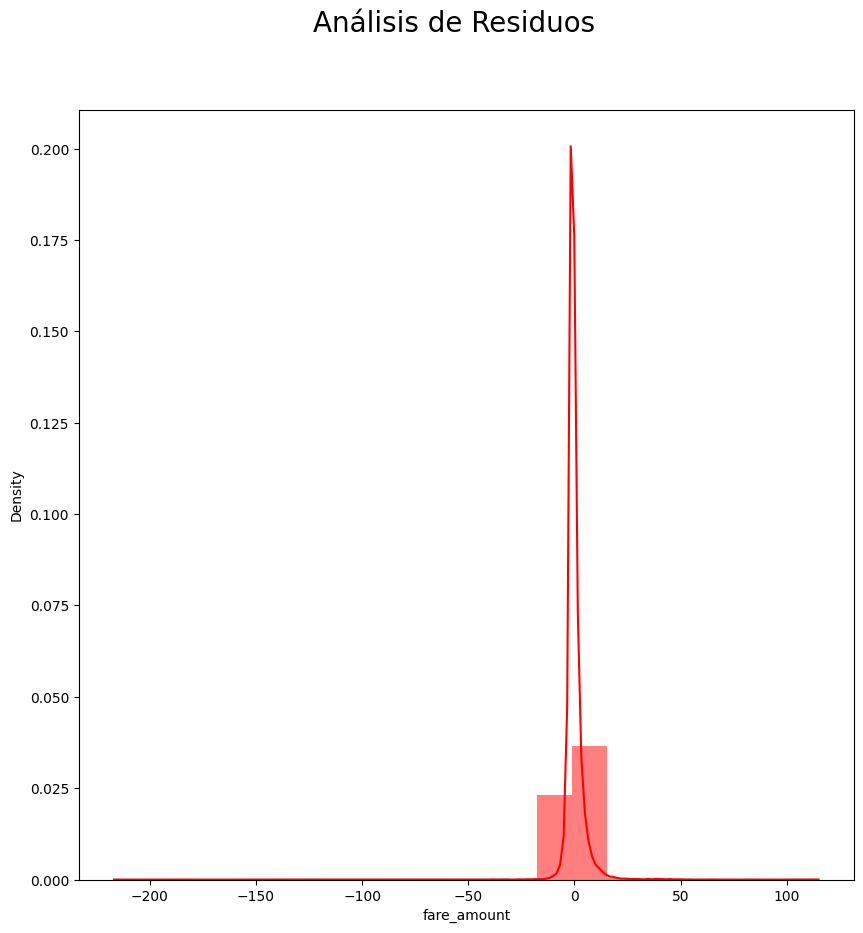

In [ ]:
fig = plt.figure(figsize=(10,10))
  
sns.histplot((y_test - predicciones_lnr.reshape(y_test.shape)), color="red", kde=True, stat="density", linewidth=0,bins=20)
fig.suptitle('Análisis de Residuos', fontsize = 20)    
plt.show()

Se detectaron 480 outliers
     y_real     y_pred    residuo
6      4.10  25.077560 -20.977560
104    3.30  29.839837 -26.539837
129   89.80  52.151605  37.648395
189   49.57   6.630435  42.939565
477   33.83  19.519142  14.310858


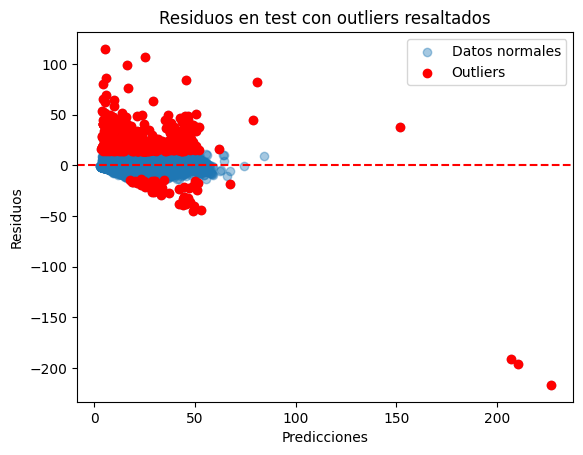

In [ ]:

# Suponiendo que y_test y y_pred ya son numpy arrays o pandas Series
y_real = np.ravel(y_test)   # convierte a array 1D
y_pred = np.ravel(y_test_pred)   # convierte a array 1D

residuos = y_real - y_pred

# Calcular media y desvío estándar
mean_res = np.mean(residuos)
std_res = np.std(residuos)

# Definir umbral (3 sigmas)
umbral = 3 * std_res

# Detectar outliers
outliers_mask = np.abs(residuos - mean_res) > umbral
outliers = pd.DataFrame({
    "y_real": y_real,
    "y_pred": y_pred,
    "residuo": residuos
})[outliers_mask]

print(f"Se detectaron {outliers.shape[0]} outliers")
print(outliers.head())

# Gráfico con outliers resaltados
plt.scatter(y_pred, residuos, alpha=0.4, label="Datos normales")
plt.scatter(outliers["y_pred"], outliers["residuo"], color="red", label="Outliers")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.legend()
plt.title("Residuos en test con outliers resaltados")
plt.show()


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, random_state=42)

In [ ]:
X_train_scaled = preprocessor.fit_transform(X_train)  # solo X_train
X_val_scaled   = preprocessor.transform(X_val)        # usar mismo scaler
X_test_scaled  = preprocessor.transform(X_test)

In [ ]:
X_train_scaled.shape, X_val_scaled.shape, X_test.shape

((137057, 40), (19580, 40), (39160, 40))

In [ ]:
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)


(137057,)
(19580,)
(39160,)


In [ ]:
y_train = y_train.values.reshape(-1,1)
y_val   = y_val.values.reshape(-1,1)
y_test  = y_test.values.reshape(-1,1)


GRADIENTE DESCENDIENTE


Época 0/200 - Train MSE: 214.7648 - Val MSE: 210.5937
Época 10/200 - Train MSE: 23.9839 - Val MSE: 22.0984
Época 20/200 - Train MSE: 23.4744 - Val MSE: 21.5265
Época 30/200 - Train MSE: 23.2627 - Val MSE: 21.3300
Época 40/200 - Train MSE: 23.1477 - Val MSE: 21.2285
Época 50/200 - Train MSE: 23.0824 - Val MSE: 21.1723
Época 60/200 - Train MSE: 23.0446 - Val MSE: 21.1409
Época 70/200 - Train MSE: 23.0224 - Val MSE: 21.1234
Época 80/200 - Train MSE: 23.0092 - Val MSE: 21.1137
Época 90/200 - Train MSE: 23.0012 - Val MSE: 21.1085
Época 100/200 - Train MSE: 22.9963 - Val MSE: 21.1056
Época 110/200 - Train MSE: 22.9932 - Val MSE: 21.1042
Época 120/200 - Train MSE: 22.9912 - Val MSE: 21.1035
Época 130/200 - Train MSE: 22.9899 - Val MSE: 21.1031
Época 140/200 - Train MSE: 22.9889 - Val MSE: 21.1030
Época 150/200 - Train MSE: 22.9882 - Val MSE: 21.1030
Época 160/200 - Train MSE: 22.9877 - Val MSE: 21.1030
Época 170/200 - Train MSE: 22.9873 - Val MSE: 21.1030
Época 180/200 - Train MSE: 22.9870 - 

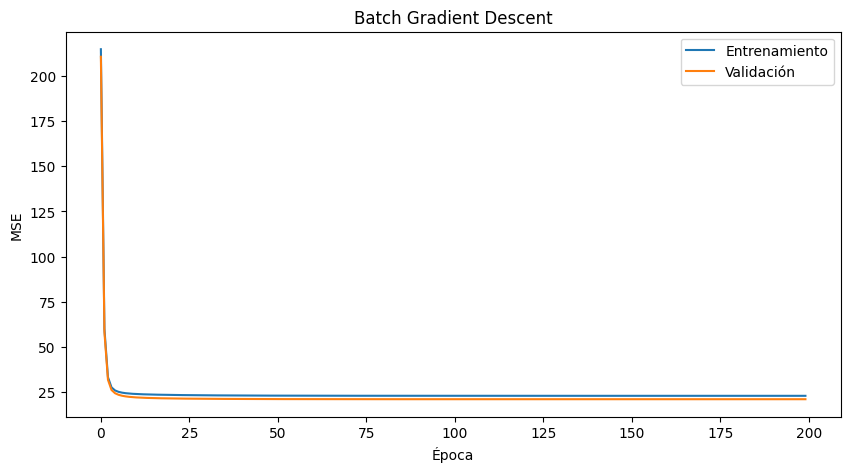

In [ ]:
def gradient_descent(X_train, y_train, X_val, y_val, lr=0.1, epochs=100, schedule=False):
    n, m = X_train.shape
    o = X_val.shape[0]

    # Agregar columna de unos (bias)
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val   = np.hstack((np.ones((o, 1)), X_val))

    # Asegurar vectores columna
    y_train = y_train.reshape(-1, 1)
    y_val   = y_val.reshape(-1, 1)

    # Inicializar pesos en cero
    W = np.zeros((m+1, 1))

    train_errors = []
    val_errors = []

    for ep in range(epochs):
        # Predicción entrenamiento
        pred_train = X_train @ W
        error_train = y_train - pred_train

        # MSE entrenamiento
        train_mse = np.mean(error_train**2)
        train_errors.append(train_mse)

        # Predicción validación
        pred_val = X_val @ W
        error_val = y_val - pred_val

        # MSE validación
        val_mse = np.mean(error_val**2)
        val_errors.append(val_mse)

        # Gradiente vectorizado: -(2/n) Xᵀ (y - XW)
        grad = -(2/n) * (X_train.T @ error_train)

        # Learning rate con schedule opcional
        lr_t = lr / np.sqrt(ep+1) if schedule else lr
        W -= lr_t * grad

        if ep % 10 == 0:
            print(f"Época {ep}/{epochs} - Train MSE: {train_mse:.4f} - Val MSE: {val_mse:.4f}")

    # Graficar
    plt.figure(figsize=(10, 5))
    plt.plot(train_errors, label='Entrenamiento')
    plt.plot(val_errors, label='Validación')
    plt.xlabel('Época')
    plt.ylabel('MSE')
    plt.legend()
    plt.title('Batch Gradient Descent')
    plt.show()

    return W



W_batch = gradient_descent(X_train_scaled, y_train, X_val_scaled, y_val, lr=0.1, epochs=200)



Gradiente Estocástico


Época 1/20 - Train MSE: 45.5310 - Test MSE: 43.2301
Época 2/20 - Train MSE: 33.4789 - Test MSE: 31.2287
Época 3/20 - Train MSE: 29.6044 - Test MSE: 27.1188
Época 4/20 - Train MSE: 27.9060 - Test MSE: 25.5699
Época 5/20 - Train MSE: 26.7840 - Test MSE: 24.4662
Época 6/20 - Train MSE: 26.0328 - Test MSE: 23.7390
Época 7/20 - Train MSE: 26.0032 - Test MSE: 23.8666
Época 8/20 - Train MSE: 25.9047 - Test MSE: 23.7174
Época 9/20 - Train MSE: 25.6253 - Test MSE: 23.4163
Época 10/20 - Train MSE: 25.3126 - Test MSE: 23.2082
Época 11/20 - Train MSE: 25.1424 - Test MSE: 22.9036
Época 12/20 - Train MSE: 25.0693 - Test MSE: 22.9596
Época 13/20 - Train MSE: 25.0350 - Test MSE: 23.0216
Época 14/20 - Train MSE: 24.9261 - Test MSE: 22.9963
Época 15/20 - Train MSE: 24.8688 - Test MSE: 22.9971
Época 16/20 - Train MSE: 24.8212 - Test MSE: 22.9701
Época 17/20 - Train MSE: 24.6926 - Test MSE: 22.8095
Época 18/20 - Train MSE: 24.5798 - Test MSE: 22.6166
Época 19/20 - Train MSE: 24.5183 - Test MSE: 22.6820
Ép

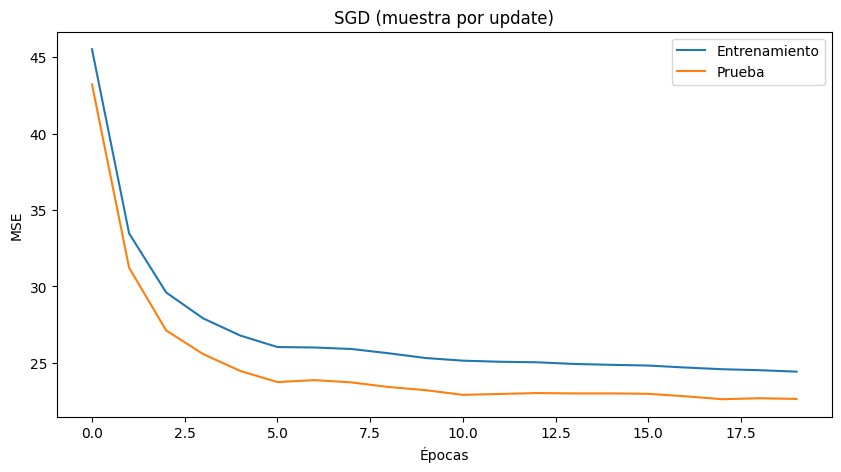

In [ ]:
def stochastic_gradient_descent(
    X_train, y_train, X_test, y_test,
    lr=0.001, epochs=20, updates_per_epoch=10000, schedule=True
):
    n, m = X_train.shape

    # Agregar bias
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test  = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.zeros((m + 1, 1))  # pesos iniciales

    train_errors, test_errors = [], []
    t = 0  # contador de updates totales

    for ep in range(epochs):
        # indices aleatorios para elegir muestras
        idx = np.random.permutation(n)
        k = min(updates_per_epoch, n)   # límite de updates por época
        pick = idx[:k]

        for j in pick:
            x_sample = X_train[j:j+1]   # (1, m+1)
            y_sample = y_train[j:j+1]   # (1, 1)

            prediction = x_sample @ W
            error = y_sample - prediction

            gradient = -2 * (x_sample.T @ error)
            lr_t = lr / np.sqrt(t+1) if schedule else lr
            W -= lr_t * gradient
            t += 1

        # calcular errores por época
        train_pred = X_train @ W
        train_mse = np.mean((y_train - train_pred)**2)
        train_errors.append(train_mse)

        test_pred = X_test @ W
        test_mse = np.mean((y_test - test_pred)**2)
        test_errors.append(test_mse)

        print(f"Época {ep+1}/{epochs} - Train MSE: {train_mse:.4f} - Test MSE: {test_mse:.4f}")

    # gráfico
    plt.figure(figsize=(10, 5))
    plt.plot(train_errors, label='Entrenamiento')
    plt.plot(test_errors, label='Prueba')
    plt.xlabel('Épocas')
    plt.ylabel('MSE')
    plt.legend()
    plt.title('SGD (muestra por update)')
    plt.show()

    return W


# Ejecutar SGD
W_sgd = stochastic_gradient_descent(X_train_scaled, y_train, X_val_scaled, y_val, lr=0.001, epochs=20)


Mini batch

Época 1/20 - Train MSE: 25.8002 - Test MSE: 24.0675
Época 2/20 - Train MSE: 24.5642 - Test MSE: 22.7349
Época 3/20 - Train MSE: 24.2007 - Test MSE: 22.3187
Época 4/20 - Train MSE: 24.0144 - Test MSE: 22.1146
Época 5/20 - Train MSE: 23.8941 - Test MSE: 21.9840
Época 6/20 - Train MSE: 23.8099 - Test MSE: 21.8751
Época 7/20 - Train MSE: 23.7449 - Test MSE: 21.8000
Época 8/20 - Train MSE: 23.6924 - Test MSE: 21.7514
Época 9/20 - Train MSE: 23.6488 - Test MSE: 21.7069
Época 10/20 - Train MSE: 23.6113 - Test MSE: 21.6676
Época 11/20 - Train MSE: 23.5789 - Test MSE: 21.6323
Época 12/20 - Train MSE: 23.5501 - Test MSE: 21.6044
Época 13/20 - Train MSE: 23.5246 - Test MSE: 21.5779
Época 14/20 - Train MSE: 23.5018 - Test MSE: 21.5550
Época 15/20 - Train MSE: 23.4806 - Test MSE: 21.5345
Época 16/20 - Train MSE: 23.4613 - Test MSE: 21.5163
Época 17/20 - Train MSE: 23.4435 - Test MSE: 21.4992
Época 18/20 - Train MSE: 23.4270 - Test MSE: 21.4843
Época 19/20 - Train MSE: 23.4117 - Test MSE: 21.4635
Ép

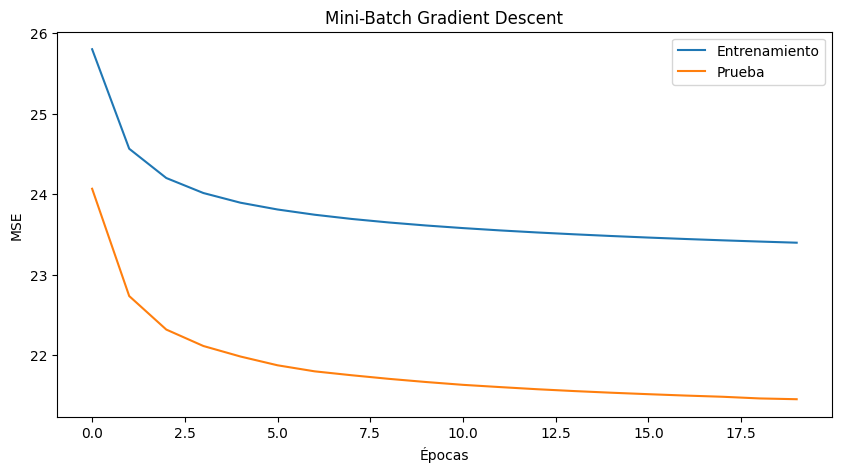

In [ ]:
def mini_batch_gradient_descent(X_train, y_train, X_test, y_test,
                                lr=0.01, epochs=20, batch_size=32, schedule=True):
    n, m = X_train.shape

    # Agregar bias
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test  = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    # Asegurar que y sean vectores columna
    y_train = y_train.reshape(-1, 1)
    y_test  = y_test.reshape(-1, 1)

    # Inicializar pesos
    W = np.zeros((m + 1, 1))

    train_errors, test_errors = [], []
    t = 0  # contador de updates

    for ep in range(epochs):
        # Permutar aleatoriamente
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]

        # Recorrer en lotes
        for j in range(0, n, batch_size):
            x_batch = X_train[j:j+batch_size]
            y_batch = y_train[j:j+batch_size]

            prediction = x_batch @ W
            error = y_batch - prediction

            gradient = -(2 / len(x_batch)) * (x_batch.T @ error)
            lr_t = lr / np.sqrt(t+1) if schedule else lr
            W -= lr_t * gradient
            t += 1

        # calcular errores globales por época
        train_mse = np.mean((y_train - (X_train @ W))**2)
        test_mse  = np.mean((y_test  - (X_test  @ W))**2)

        train_errors.append(train_mse)
        test_errors.append(test_mse)

        print(f"Época {ep+1}/{epochs} - Train MSE: {train_mse:.4f} - Test MSE: {test_mse:.4f}")

    # gráfico
    plt.figure(figsize=(10, 5))
    plt.plot(train_errors, label='Entrenamiento')
    plt.plot(test_errors, label='Prueba')
    plt.xlabel('Épocas')
    plt.ylabel('MSE')
    plt.legend()
    plt.title('Mini-Batch Gradient Descent')
    plt.show()

    return W


W_mini = mini_batch_gradient_descent(X_train_scaled, y_train, X_val_scaled, y_val, lr=0.01, epochs=20, batch_size=200)



REGULARIZACIÓN


RIDGE
---

In [ ]:

modelo_ridge = RidgeCV(
    alphas = np.logspace(-4, 4, 100),
    cv=5,
    fit_intercept=True,
)
modelo_ridge.fit(X_train_scaled, y_train)

# Evaluar en el set de validación
y_val_pred = modelo_ridge.predict(X_val_scaled)
mse_val = mean_squared_error(y_val, y_val_pred)
print("MSE en validación:", mse_val)


MSE en validación: 21.12941761633198


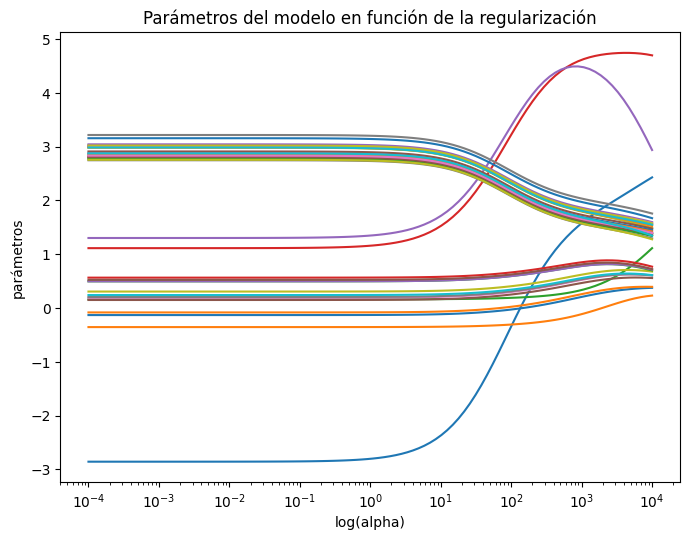

In [ ]:

alphas = modelo_ridge.alphas
coefs = []

for alpha in alphas:
    modelo_temp = Ridge(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(X_train_scaled, y_train)
    coefs.append(modelo_temp.coef_.flatten())

fig, ax = plt.subplots(figsize=(8, 5.84))
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_xlabel('log(alpha)')
ax.set_ylabel('parámetros')
ax.set_title('Parámetros del modelo en función de la regularización');
plt.axis('tight')
plt.show()

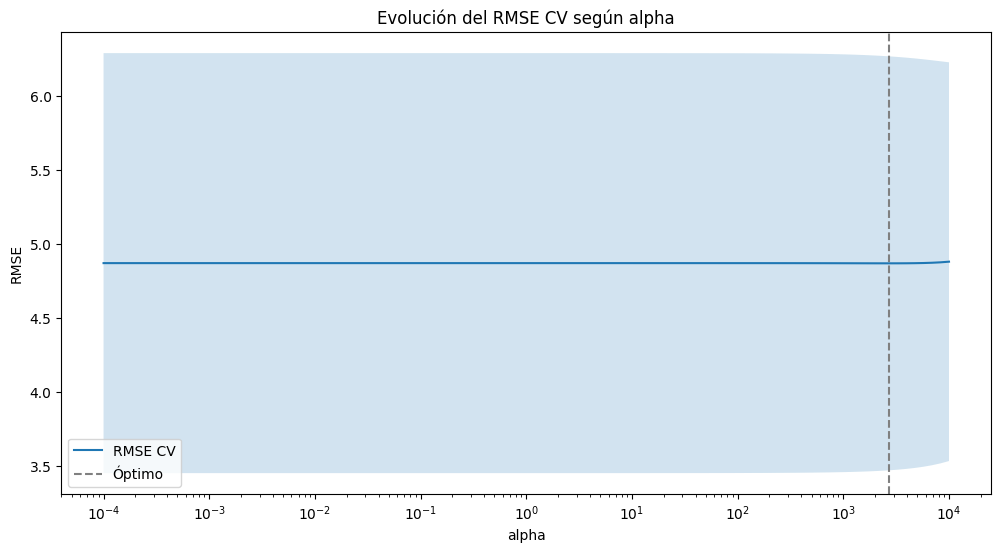

In [ ]:
alphas = np.logspace(-4, 4, 100)
rmse_mean = []
rmse_std  = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for alpha in alphas:
    ridge = Ridge(alpha=alpha, fit_intercept=True)
    
    # cross_val_score devuelve score (por defecto R^2), usamos scoring="neg_mean_squared_error"
    mse_scores = -cross_val_score(ridge, X_train_scaled, y_train,
                                  cv=kf,
                                  scoring="neg_mean_squared_error")
    
    rmse_mean.append(np.sqrt(mse_scores.mean()))
    rmse_std.append(np.sqrt(mse_scores.std()))

rmse_mean = np.array(rmse_mean)
rmse_std  = np.array(rmse_std)

# Alpha óptimo
optimo = alphas[np.argmin(rmse_mean)]

# Gráfico
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(alphas, rmse_mean, label="RMSE CV")
ax.fill_between(alphas, rmse_mean - rmse_std, rmse_mean + rmse_std, alpha=0.2)
ax.axvline(optimo, linestyle="--", color="gray", label="Óptimo")
ax.set_xscale('log')
ax.set_xlabel("alpha")
ax.set_ylabel("RMSE")
ax.set_title("Evolución del RMSE CV según alpha")
ax.legend()
plt.show()

In [ ]:
print(f"Mejor valor de alpha encontrado: {modelo_ridge.alpha_}")

Mejor valor de alpha encontrado: 2257.0197196339213


In [ ]:
predicciones_ridge = modelo_ridge.predict(X = X_test_scaled)
predicciones_ridge = predicciones_ridge.flatten()
predicciones_ridge[:10]

array([ 7.22027897,  7.61257505,  9.49228022,  8.95273808, 12.68072117,
       16.76819781, 24.8604641 ,  7.39591342,  6.36743229, 14.55791221])

In [ ]:
rmse_ridge = np.sqrt(mean_squared_error(y_test, predicciones_ridge))
print(f"El error (rmse) de test es: {rmse_ridge}")

El error (rmse) de test es: 4.61963805329489


In [ ]:
import sklearn.metrics as metrics
R2 = metrics.r2_score(y_test, predicciones_ridge)
R2

0.768806980954534

0.7449606407520231


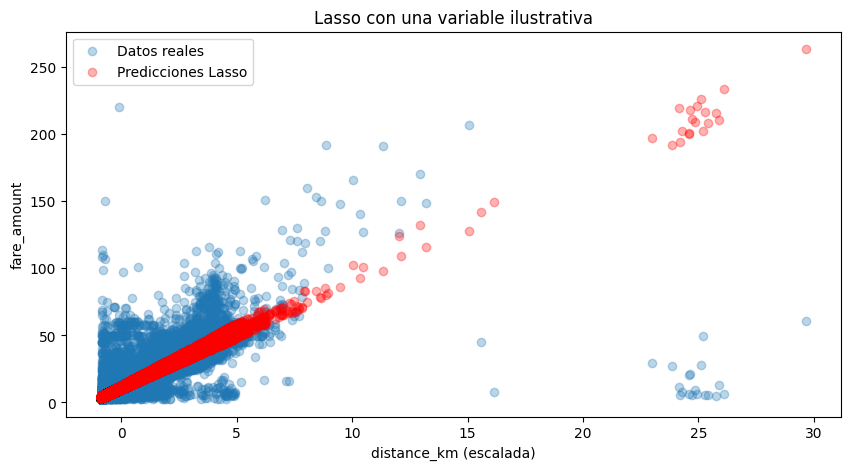

In [ ]:
lasso = Lasso(alpha=0.001)
lasso.fit(X_train_scaled, y_train)
print(lasso.score(X_train_scaled,np.array(y_train).reshape(-1,1)))
##Graficar los coeficientes
# Supongamos que la columna 5 es 'distance_km'
i = 0

plt.figure(figsize=(10,5))
plt.scatter(X_train_scaled[:, i], y_train, alpha=0.3, label='Datos reales')
plt.scatter(X_train_scaled[:, i], lasso.predict(X_train_scaled), 
            color='red', alpha=0.3, label='Predicciones Lasso')
plt.xlabel("distance_km (escalada)")
plt.ylabel("fare_amount")
plt.title("Lasso con una variable ilustrativa")
plt.legend()
plt.show()


R² en train: 0.7423805752768835


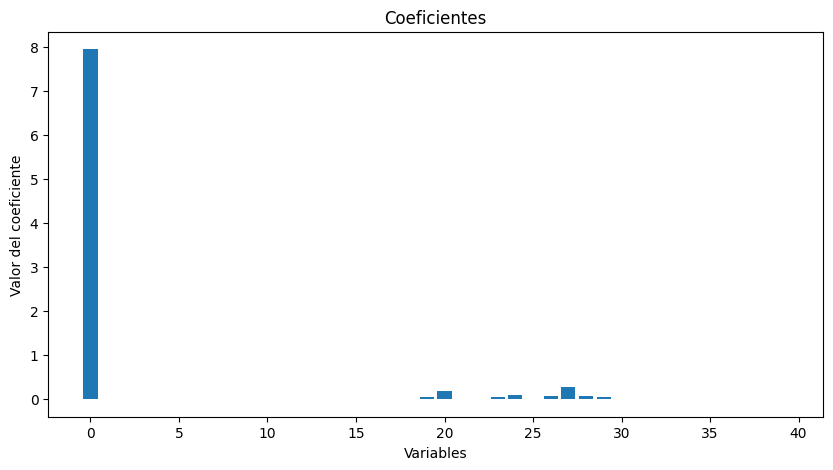

In [ ]:

lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

print("R² en train:", lasso.score(X_train_scaled, y_train))

# Graficar coeficientes con nombres de variables
plt.figure(figsize=(10, 5))
plt.bar(range(len(lasso.coef_)), lasso.coef_)
plt.xlabel("Variables")
plt.ylabel("Valor del coeficiente")
plt.title("Coeficientes")
plt.show()


LASSO
---

Mejor alpha encontrado: 0.298364724028334


c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.650e+04, tolerance: 2.944e+03
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.913e+04, tolerance: 2.944e+03
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iteration

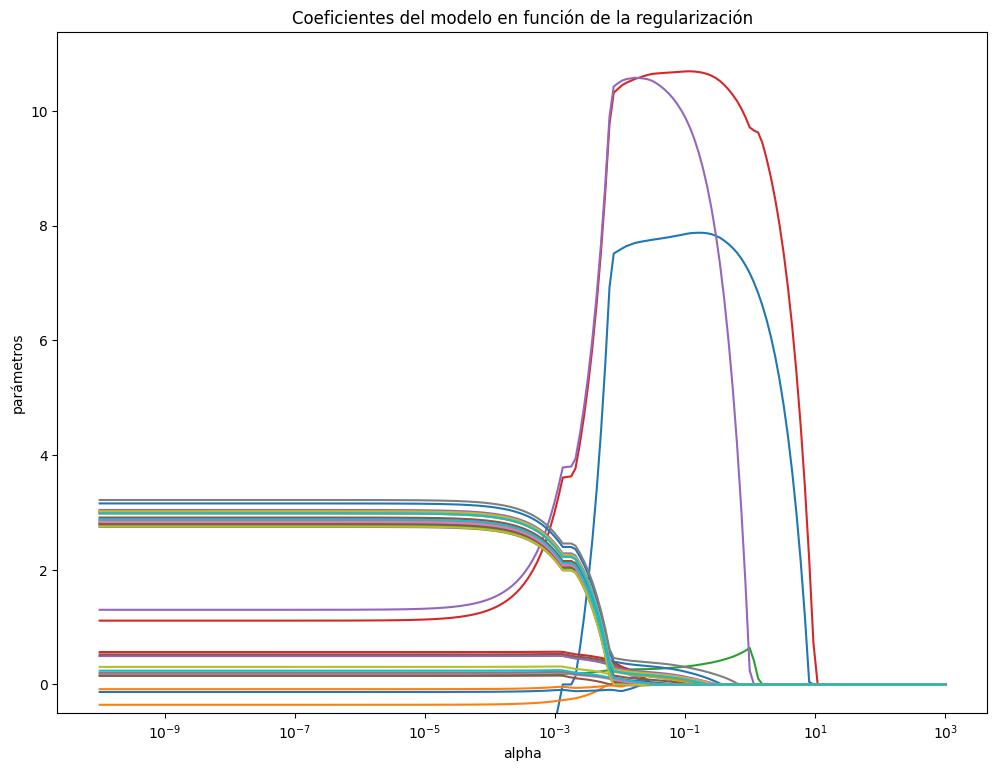

In [ ]:
from sklearn.linear_model import lasso_path
modelo = LassoCV(alphas = np.logspace(-4, 4, 100), cv=10)
modelo.fit(X_train_scaled, y_train.flatten())           #TODAVIA ME FALTA REPASAR DONDE VA X_VAL_SCALED
print("Mejor alpha encontrado:", modelo.alpha_)

# Usar lasso_path para obtener coeficientes en un rango de alphas
alphas_lasso, coefs_lasso, _ = lasso_path(X_train_scaled, y_train.flatten(), alphas=np.logspace(-10, 3, 200))

# Graficar
fig, ax = plt.subplots(figsize=(12, 8.84))
ax.plot(alphas_lasso, coefs_lasso.T)   # transponer para graficar cada coef
ax.set_xscale('log')
ax.set_ylim([-0.5, None])
ax.set_xlabel('alpha')
ax.set_ylabel('parámetros')
ax.set_title('Coeficientes del modelo en función de la regularización')
plt.show()




lo de abajo tarda muchisimo
---


In [ ]:
"""
alphas = modelo.alphas_
n_predictores = []

for alpha in alphas:
    modelo_temp = Lasso(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(X_train_scaled, y_train)
    coef_no_cero = np.sum(modelo_temp.coef_.flatten() != 0)
    n_predictores.append(coef_no_cero)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(alphas, n_predictores)
ax.set_xscale('log')
ax.set_ylim([-0.5,None])
ax.set_xlabel('alpha')
ax.set_ylabel('nº parámetros')
ax.set_title('Features incluidas en función de la regularización')
"""

KeyboardInterrupt: 

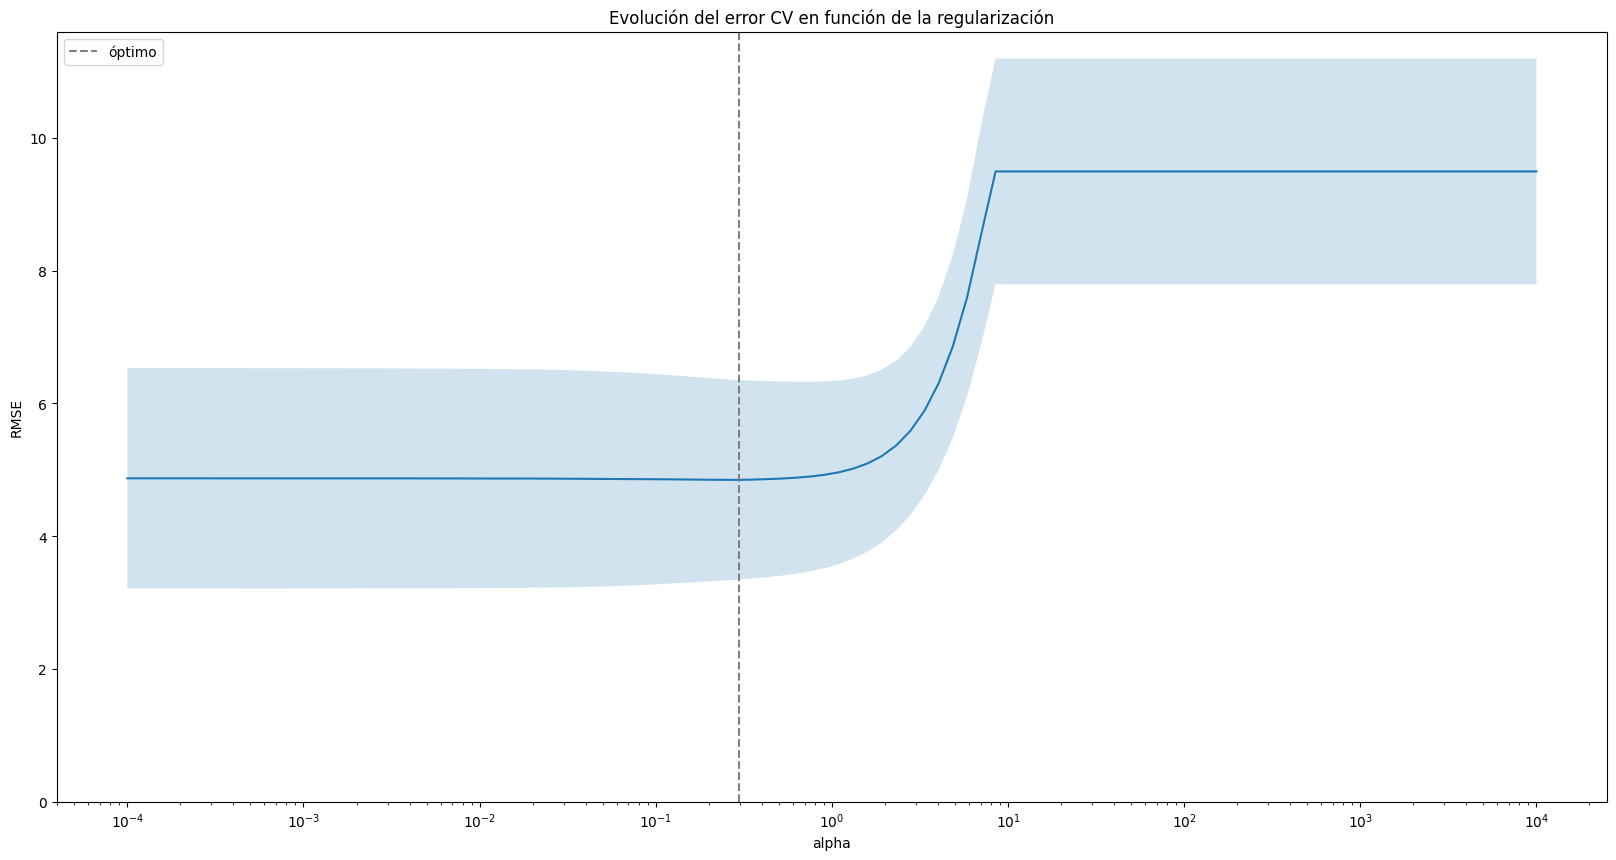

In [ ]:
# Evolución del error de validación cruzada en función de alpha

mse_cv = modelo.mse_path_.mean(axis=1)
mse_sd = modelo.mse_path_.std(axis=1)

# Se aplica la raíz cuadrada para pasar de mse a rmse
rmse_cv = np.sqrt(mse_cv)
rmse_sd = np.sqrt(mse_sd)

# Se identifica el óptimo y el óptimo + 1std
min_rmse     = np.min(rmse_cv)
optimo       = modelo.alphas_[np.argmin(rmse_cv)]

# Gráfico del error +- 1 desviación estándar
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(modelo.alphas_, rmse_cv)
ax.fill_between(
    modelo.alphas_,
    rmse_cv + rmse_sd,
    rmse_cv - rmse_sd,
    alpha=0.2
)

ax.axvline(
    x         = optimo,
    c         = "gray",
    linestyle = '--',
    label     = 'óptimo'
)

ax.set_xscale('log')
ax.set_ylim([0,None])
ax.set_title('Evolución del error CV en función de la regularización')
ax.set_xlabel('alpha')
ax.set_ylabel('RMSE')
plt.legend()

In [ ]:
print(f"Mejor valor de alpha encontrado: {modelo.alpha_}")

Mejor valor de alpha encontrado: 0.0001


In [ ]:
df_coeficientes = pd.DataFrame(
                        {'predictor': X_train.columns,
                         'coef': modelo.coef_.flatten()}
                  )

df_coeficientes[df_coeficientes.coef != 0]

,predictor,coef
0,distance_km,7.850461
27,mes_2,0.091889


In [ ]:
predicciones_lasso = modelo.predict(X=X_test_scaled) #Hacerlo con el x_val_scaled para ver el error en validación?
predicciones_lasso = predicciones_lasso.flatten()
predicciones_lasso[:10]

array([ 7.37002355,  7.88861662,  9.54516698,  8.95602259, 13.13511999,
       16.94239675, 25.33019542,  7.81785644,  6.63953669, 13.9882496 ])

In [ ]:
rmse_lasso = np.sqrt(mean_squared_error(y_test, predicciones_lasso))
print(f"El error (rmse) de test es: {rmse_lasso}")

El error (rmse) de test es: 4.6747010147333645


In [ ]:
R2 = metrics.r2_score(y_test, predicciones_lasso)
R2

0.7632628064252283

ELASTIC NET 
---


In [ ]:
modelo_elast = ElasticNetCV(
            l1_ratio        = [0.1, 0.5, 0.9], #Tuve que cambiar esto del original
            alphas          = np.logspace(-4, 2, 100), #Esto tambien
            cv              = 5,
            max_iter        = 10000
         )
_ = modelo_elast.fit(X = X_train_scaled, y = y_train.flatten())


In [ ]:
# Predicciones con los mejores parámetros
pred = modelo_elast.predict(X_val_scaled)

# RMSE
rmse_elastic = np.sqrt(mean_squared_error(y_val, pred))
print("Alpha óptimo:", modelo_elast.alpha_)
print("L1_ratio óptimo:", modelo_elast.l1_ratio_)
print("RMSE en validación:", rmse)


Alpha óptimo: 0.10722672220103231
L1_ratio óptimo: 0.9
RMSE en validación: 4.610636422284684


In [ ]:
# Error medio de las 10 particiones por cada valor de alpha y l1_ratio 
mean_error_cv = modelo_elast.mse_path_.mean(axis =2)

# El resultado es un array de dimensiones (n_l1_ratio, n_alpha) se convierte en un dataframe
df_resultados_cv = pd.DataFrame(
                        data   = mean_error_cv.flatten(),
                        index  = pd.MultiIndex.from_product(
                                    iterables = [modelo_elast.l1_ratio, modelo_elast.alphas_],
                                    names     = ['l1_ratio', 'modelo.alphas_']
                                 ),
                        columns = ["mse_cv"]
                    )

df_resultados_cv['rmse_cv'] = np.sqrt(df_resultados_cv['mse_cv'])
df_resultados_cv = df_resultados_cv.reset_index().sort_values('mse_cv', ascending = True)
df_resultados_cv

,l1_ratio,modelo.alphas_,mse_cv,rmse_cv
249,0.9,0.107227,23.591957,4.857155
248,0.9,0.123285,23.592021,4.857162
247,0.9,0.141747,23.593103,4.857273
250,0.9,0.093260,23.595535,4.857524
251,0.9,0.081113,23.600980,4.858084
...,...,...,...,...
104,0.5,57.223677,90.116179,9.492954
103,0.5,65.793322,90.116179,9.492954
102,0.5,75.646333,90.116179,9.492954
112,0.5,18.738174,90.116179,9.492954


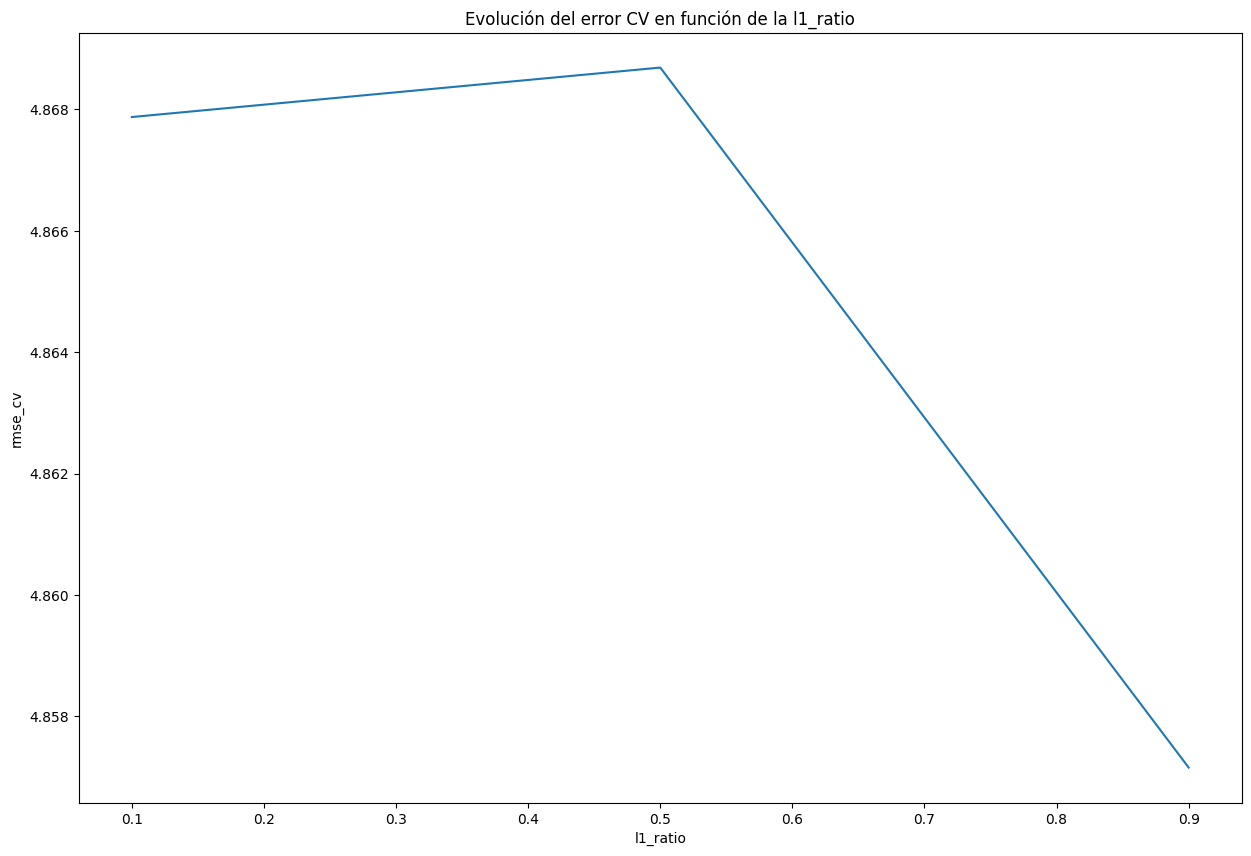

In [ ]:
fig, ax = plt.subplots(figsize=(15, 10))
df_resultados_cv.groupby('l1_ratio')['rmse_cv'].min().plot(ax = ax)
ax.set_title('Evolución del error CV en función de la l1_ratio')
ax.set_xlabel('l1_ratio')
ax.set_ylabel('rmse_cv');

In [ ]:
print("Mejor alpha:", modelo_elast.alpha_)
print("Mejor l1_ratio:", modelo_elast.l1_ratio_)

Mejor alpha: 0.10722672220103231
Mejor l1_ratio: 0.9


In [ ]:
pred_val = modelo_elast.predict(X_test_scaled)
pred_val = pred_val.flatten()

In [ ]:
import sklearn.metrics as metrics
R2 = metrics.r2_score(y_test, pred_val)
R2

0.7661627471270851

Comparación de Modelos

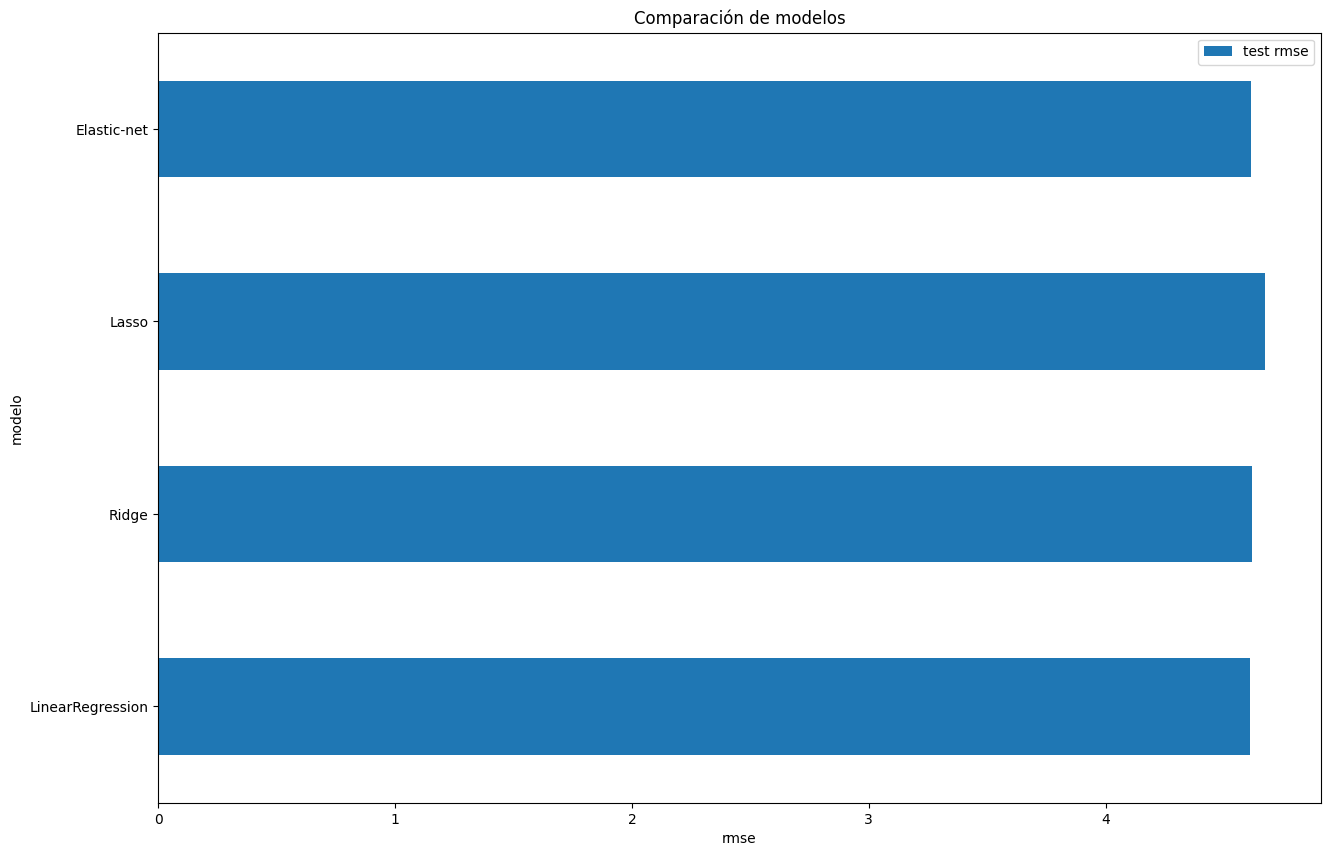

In [ ]:
df_comparacion = pd.DataFrame({
                    'modelo': ['LinearRegression', 'Ridge', 'Lasso', 'Elastic-net'],
                    'test rmse': [rmse_ols, rmse_ridge, rmse_lasso, rmse_elastic]
                 })

fig, ax = plt.subplots(figsize=(15, 10))
df_comparacion.set_index('modelo').plot(kind='barh', ax=ax)
ax.set_xlabel('rmse')
ax.set_ylabel('modelo')
ax.set_title('Comparación de modelos');

HICE HASTA LO DE ARRIBA
--------


----------------------------------------------------------------------------------------------------------------